# Stabilized Animal Trajectory Analysis

Visualizations use **camera-motion-compensated coordinates** from `08b_tracking.py`.
Static plots use the **chosen reference frame** as the map background; videos play the full stabilized sequence.

In [1]:
import ast
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Video, display
from matplotlib.colors import LinearSegmentedColormap

from config import MODEL_NAME

TRACK_NUMBER = "10_BEST"
OUTPUT_ROOT = Path("runs/detect/track") / f"track_{MODEL_NAME}_{TRACK_NUMBER}"
STABILIZED_DIR = OUTPUT_ROOT / "stabilized_frames"
TRAJ_JSON = OUTPUT_ROOT / "trajectories.json"
TRAJ_TXT = OUTPUT_ROOT / "trajectories.txt"
TRACKING_VIDEO = OUTPUT_ROOT / "tracking_overlay_video.mp4"
TRAJECTORY_VIDEO = OUTPUT_ROOT / "stabilized_trajectory_video.mp4"
REFERENCE_IMAGE = OUTPUT_ROOT / "reference_frame.jpg"
VIDEO_FPS = 5
TRAIL_LENGTH = 30
MIN_TRACK_LENGTH = 2


def load_tracking_data(path_json: Path, path_txt: Path):
    metadata = {"reference_frame_index": 0, "reference_frame_name": "frame_0"}
    if path_json.exists():
        with open(path_json, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        metadata["reference_frame_index"] = int(payload.get("reference_frame_index", 0))
        metadata["reference_frame_name"] = payload.get("reference_frame_name", "frame_0")
        trajectories = {
            int(obj_id): [(float(x), float(y)) for x, y in points]
            for obj_id, points in payload["trajectories"].items()
        }
        frame_tracks = {}
        for frame_idx, tracks in payload.get("frame_tracks", {}).items():
            frame_tracks[int(frame_idx)] = {
                int(obj_id): (float(xy[0]), float(xy[1]))
                for obj_id, xy in tracks.items()
            }
        return trajectories, frame_tracks, metadata

    trajectories = {}
    with open(path_txt, "r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            id_part, points_part = line.split(":", 1)
            obj_id = int(id_part.replace("ID", "").strip())
            trajectories[obj_id] = ast.literal_eval(points_part.strip())
    return trajectories, {}, metadata


def load_stabilized_paths(stabilized_dir: Path) -> list[Path]:
    return sorted(stabilized_dir.glob("*.jpg")) + sorted(stabilized_dir.glob("*.png"))


def load_stabilized_frame(stabilized_paths: list[Path], frame_idx: int) -> np.ndarray:
    image = cv2.imread(str(stabilized_paths[frame_idx]))
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def load_reference_image(output_root: Path, stabilized_paths: list[Path], ref_idx: int) -> np.ndarray:
    ref_path = output_root / "reference_frame.jpg"
    if ref_path.exists():
        image = cv2.imread(str(ref_path))
    else:
        image = cv2.imread(str(stabilized_paths[ref_idx]))
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def filter_trajectories(trajectories, min_length: int = MIN_TRACK_LENGTH):
    return {
        obj_id: points
        for obj_id, points in trajectories.items()
        if obj_id >= 0 and len(points) >= min_length
    }


def path_length(points: list[tuple[float, float]]) -> float:
    if len(points) < 2:
        return 0.0
    total = 0.0
    for i in range(1, len(points)):
        p1 = np.array(points[i - 1])
        p2 = np.array(points[i])
        total += float(np.linalg.norm(p2 - p1))
    return total


def track_color(obj_id: int):
    return plt.colormaps["tab20"](obj_id % 20)


def track_color_bgr(obj_id: int) -> tuple[int, int, int]:
    rgba = track_color(obj_id)
    return (int(rgba[2] * 255), int(rgba[1] * 255), int(rgba[0] * 255))


trajectories_raw, frame_tracks, metadata = load_tracking_data(TRAJ_JSON, TRAJ_TXT)
trajectories = filter_trajectories(trajectories_raw)
stabilized_paths = load_stabilized_paths(STABILIZED_DIR)
reference_idx = metadata["reference_frame_index"]
reference_name = metadata["reference_frame_name"]
reference_img = load_reference_image(OUTPUT_ROOT, stabilized_paths, reference_idx)
num_frames = len(stabilized_paths)
print(f"Loaded {len(trajectories)} trajectories, {num_frames} stabilized frames")
print(f"Reference frame: {reference_name} (index {reference_idx})")

Loaded 7 trajectories, 42 stabilized frames
Reference frame: 10_3158.jpg (index 14)


## VIS 0 — Video playback (full stabilized sequence)
These videos advance through **all stabilized frames**, aligned to the reference image.

In [2]:
def create_stabilized_trajectory_video(
    stabilized_paths: list[Path],
    frame_tracks: dict[int, dict[int, tuple[float, float]]],
    output_path: Path,
    fps: int = VIDEO_FPS,
    trail_length: int = TRAIL_LENGTH,
) -> Path:
    if not stabilized_paths:
        raise FileNotFoundError("No stabilized frames found")

    histories: dict[int, list[tuple[int, int]]] = {}
    sample = cv2.imread(str(stabilized_paths[0]))
    height, width = sample.shape[:2]
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    for frame_idx, image_path in enumerate(stabilized_paths):
        frame = cv2.imread(str(image_path))
        tracks = frame_tracks.get(frame_idx, {})
        annotated = frame.copy()

        for obj_id, (x, y) in tracks.items():
            point = (int(round(x)), int(round(y)))
            history = histories.setdefault(int(obj_id), [])
            history.append(point)
            if len(history) > trail_length:
                history.pop(0)

        for obj_id, history in histories.items():
            color = track_color_bgr(obj_id)
            for j in range(1, len(history)):
                cv2.line(annotated, history[j - 1], history[j], color, 2)
            if obj_id in tracks:
                cx = int(round(tracks[obj_id][0]))
                cy = int(round(tracks[obj_id][1]))
                cv2.circle(annotated, (cx, cy), 5, color, -1)
                cv2.putText(
                    annotated,
                    f"ID {obj_id}",
                    (cx + 6, max(20, cy - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    color,
                    2,
                    cv2.LINE_AA,
                )

        cv2.putText(
            annotated,
            f"Frame {frame_idx + 1}/{len(stabilized_paths)}",
            (16, 36),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )
        writer.write(annotated)

    writer.release()
    return output_path


def show_video(path: Path, title: str) -> None:
    if not path.exists():
        print(f"Missing: {path}")
        return
    display(HTML(f"<h4>{title}</h4>"))
    display(Video(str(path), embed=True, width=720))


if frame_tracks:
    create_stabilized_trajectory_video(stabilized_paths, frame_tracks, TRAJECTORY_VIDEO)
    print(f"Saved: {TRAJECTORY_VIDEO}")
else:
    print("No per-frame tracks in JSON — re-run 08b_tracking.py to enable trajectory video generation.")

show_video(TRACKING_VIDEO, "Tracking overlay video (boxes + IDs + trails)")
show_video(TRAJECTORY_VIDEO, "Stabilized sequence video (changing background + trails)")

Saved: runs\detect\track\track_yolo26s_annotated_10_BEST\stabilized_trajectory_video.mp4


## VIS 1 — Trajectories over stabilized reference frame
Summary map on frame 0: start markers (circle), end markers (cross), and ID labels.

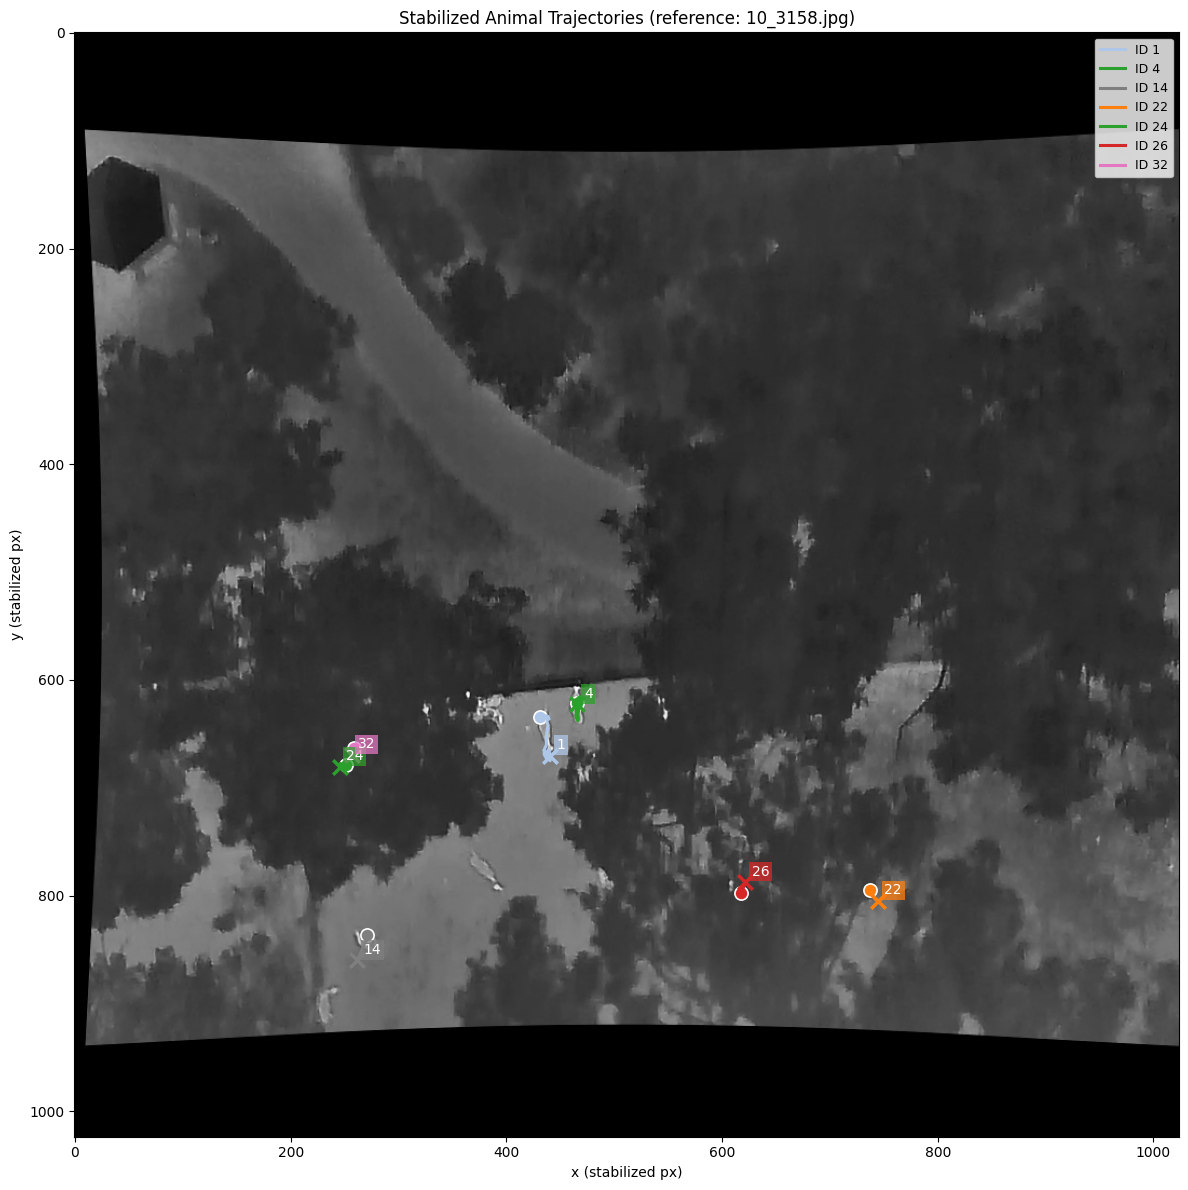

Saved trajectory plot: runs\detect\track\track_yolo26s_annotated_10_BEST\trajectories_on_reference.png


In [3]:
def plot_trajectories_on_reference(reference, trajectories):
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(reference, cmap="gray")

    for obj_id, points in sorted(trajectories.items()):
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        color = track_color(obj_id)
        ax.plot(xs, ys, color=color, linewidth=2.2, label=f"ID {obj_id}")
        ax.scatter(xs[0], ys[0], s=90, marker="o", color=color, edgecolors="white", linewidths=1.2)
        ax.scatter(xs[-1], ys[-1], s=110, marker="x", color=color, linewidths=2.5)
        ax.text(xs[-1] + 6, ys[-1] - 6, str(obj_id), color="white", fontsize=10,
                bbox=dict(facecolor=color, alpha=0.75, pad=2, edgecolor="none"))

    ax.set_title(f"Stabilized Animal Trajectories (reference: {reference_name})")
    ax.set_xlabel("x (stabilized px)")
    ax.set_ylabel("y (stabilized px)")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()
    #save plot:
    plot_path = OUTPUT_ROOT / "trajectories_on_reference.png"
    fig.savefig(plot_path, dpi=300)
    print(f"Saved trajectory plot: {plot_path}")


plot_trajectories_on_reference(reference_img, trajectories)

## VIS 2 — Animal presence density heatmap

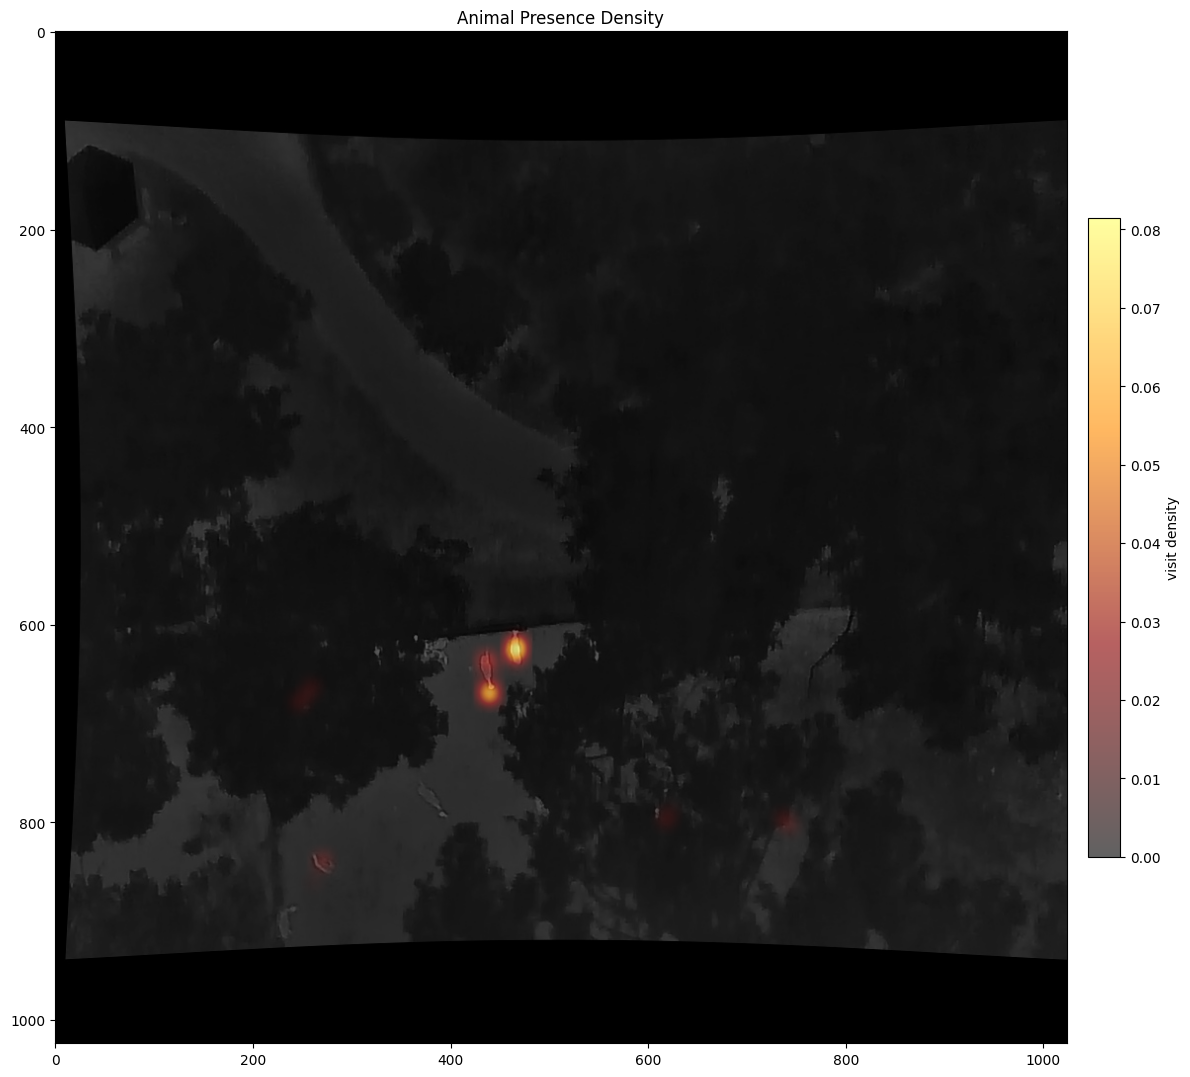

Saved density heatmap: runs\detect\track\track_yolo26s_annotated_10_BEST\trajectory_density_heatmap.png


In [4]:
def build_density_map(trajectories, shape, sigma: float = 8.0):
    h, w = shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for points in trajectories.values():
        for x, y in points:
            xi, yi = int(round(x)), int(round(y))
            if 0 <= xi < w and 0 <= yi < h:
                density[yi, xi] += 1.0
    if sigma > 0:
        ksize = int(max(3, sigma * 4)) | 1
        density = cv2.GaussianBlur(density, (ksize, ksize), sigma)
    return density


def plot_density_heatmap(reference, density):
    fire = LinearSegmentedColormap.from_list("thermal_fire", ["#000000", "#8b0000", "#ff8c00", "#ffff66"])
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(reference, cmap="gray")
    heat = ax.imshow(density, cmap=fire, alpha=0.62)
    ax.set_title("Animal Presence Density")
    fig.colorbar(heat, ax=ax, fraction=0.03, pad=0.02, label="visit density")
    plt.tight_layout()
    plt.show()
    #save plot:
    plot_path = OUTPUT_ROOT / "trajectory_density_heatmap.png"
    fig.savefig(plot_path, dpi=300)
    print(f"Saved density heatmap: {plot_path}")


plot_density_heatmap(reference_img, build_density_map(trajectories, reference_img.shape))

## VIS 3 — Total distance traveled per animal

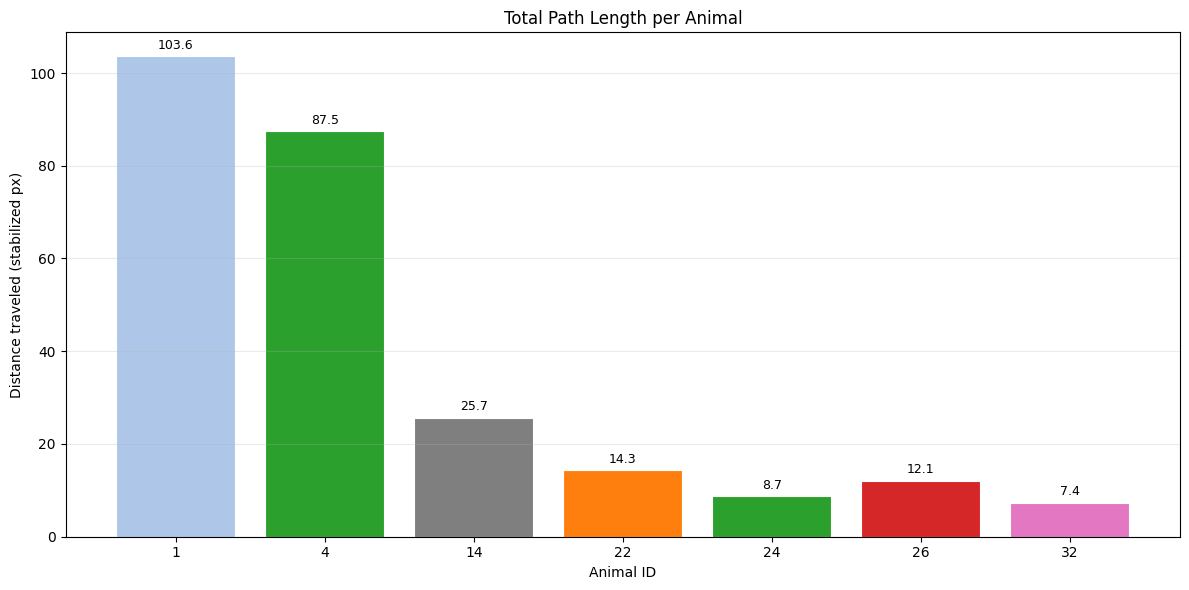

Saved distance traveled plot: runs\detect\track\track_yolo26s_annotated_10_BEST\distance_traveled.png


In [5]:
def plot_distance_traveled(trajectories):
    distances = {obj_id: path_length(points) for obj_id, points in trajectories.items()}
    ids = sorted(distances)
    vals = [distances[i] for i in ids]
    colors = [track_color(i) for i in ids]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar([str(i) for i in ids], vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_xlabel("Animal ID")
    ax.set_ylabel("Distance traveled (stabilized px)")
    ax.set_title("Total Path Length per Animal")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    #save plot:
    plot_path = OUTPUT_ROOT / "distance_traveled.png"
    fig.savefig(plot_path, dpi=300)
    print(f"Saved distance traveled plot: {plot_path}")


plot_distance_traveled(trajectories)

## VIS 4 — Interactive sequence playback
Scrub through **actual stabilized frames** with growing trails (not a frozen background).

In [6]:
# try:
#     import ipywidgets as widgets
#     HAS_WIDGETS = True
# except ImportError:
#     HAS_WIDGETS = False
#     print("ipywidgets not installed — use the videos in VIS 0 instead.")


# def make_sequence_playback_widget(stabilized_paths, frame_tracks):
#     fig, ax = plt.subplots(figsize=(10, 10))
#     image_artist = ax.imshow(load_stabilized_frame(stabilized_paths, 0), cmap="gray")
#     lines = {}
#     points = {}
#     title = ax.set_title("")
#     ax.set_axis_off()

#     def update(frame_idx: int) -> None:
#         frame_idx = max(0, min(frame_idx, len(stabilized_paths) - 1))
#         image_artist.set_data(load_stabilized_frame(stabilized_paths, frame_idx))

#         histories: dict[int, list[tuple[float, float]]] = {}
#         for f_idx in range(frame_idx + 1):
#             for obj_id, xy in frame_tracks.get(f_idx, {}).items():
#                 histories.setdefault(obj_id, []).append(xy)

#         for artist in list(lines.values()) + list(points.values()):
#             artist.remove()
#         lines.clear()
#         points.clear()

#         for obj_id, history in histories.items():
#             if len(history) < 1:
#                 continue
#             color = track_color(obj_id)
#             xs = [p[0] for p in history]
#             ys = [p[1] for p in history]
#             lines[obj_id], = ax.plot(xs, ys, color=color, linewidth=2.2)
#             points[obj_id] = ax.scatter(xs[-1], ys[-1], s=70, color=color, edgecolors="white")

#         title.set_text(f"Stabilized frame {frame_idx + 1}/{len(stabilized_paths)}")
#         fig.canvas.draw_idle()

#     frame_slider = widgets.IntSlider(
#         min=0,
#         max=max(0, len(stabilized_paths) - 1),
#         step=1,
#         value=0,
#         description="Frame:",
#         continuous_update=True,
#     )
#     widgets.interact(update, frame_idx=frame_slider)


# if frame_tracks and HAS_WIDGETS:
#     make_sequence_playback_widget(stabilized_paths, frame_tracks)
# elif not frame_tracks:
#     print("Re-run 08b_tracking.py to get per-frame data for interactive playback.")